In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset = pd.read_csv('tickets.csv')

In [ ]:
print(corpus)

['non reflection of payment i paid for change of programme and i wa debited but the money is not reflecting on portal so i couldn t proceed to change my course instead is asking me to make another payment', 'unable to pay school fee dear sir i m having issue with school fee payment the payment is not effected after imputing the a required it always take me to payment history this ha been happening since thanks', 'biodata not reflecting bio data not reflecting', 'downloading of biodata clearance i wa unable to download my biodata clearance fully when i downloaded it it will only show blank space with only school heading', 'downloading of biodata clearance i wa unable to download my biodata clearance successfully when i downloaded it it will only the school heading i am looking forward to hearing from you soon', 'medical have pay medical and it did not reflect on my portal', 'form please i can see the information on my bio data form it is blank', 'biodata clearance hasn t been batched go

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer ('all-MiniLM-L6-v2') #('sentence-transformers/sentence-t5-base')
X = model.encode(corpus, show_progress_bar=True)
# model.save("embedding_model")


Batches:   0%|          | 0/569 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
print(X)

[[ 0.02296173 -0.01373432  0.0149591  ... -0.0575704   0.01515084
  -0.09662001]
 [-0.02621975  0.06262407  0.08070537 ... -0.03429516  0.03791189
  -0.02803639]
 [ 0.06032454 -0.03495183 -0.01916061 ... -0.05817263 -0.04923449
  -0.0694534 ]
 ...
 [-0.0060409   0.00396088  0.00165242 ... -0.07245175  0.03563897
  -0.04130106]
 [-0.0060409   0.00396088  0.00165242 ... -0.07245175  0.03563897
  -0.04130106]
 [ 0.01120861 -0.0498368   0.00545335 ...  0.04270301  0.00637126
  -0.07086156]]


In [ ]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=5, random_state=42)
X = svd.fit_transform(X)


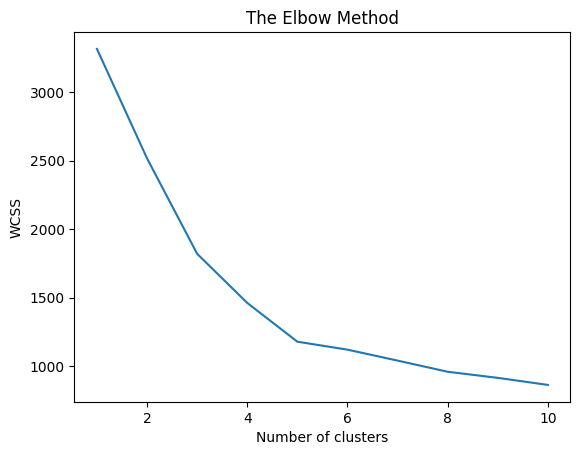

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [ ]:
from google.colab import files

model.save("embedding_model")

# Zip the folder
!zip -r embedding_model.zip embedding_model

# Download the zip
files.download("embedding_model.zip")


updating: embedding_model/ (stored 0%)
updating: embedding_model/special_tokens_map.json (deflated 80%)
updating: embedding_model/2_Normalize/ (stored 0%)
updating: embedding_model/tokenizer_config.json (deflated 73%)
updating: embedding_model/1_Pooling/ (stored 0%)
updating: embedding_model/1_Pooling/config.json (deflated 59%)
updating: embedding_model/README.md (deflated 64%)
updating: embedding_model/model.safetensors (deflated 9%)
updating: embedding_model/config.json (deflated 48%)
updating: embedding_model/sentence_bert_config.json (deflated 9%)
updating: embedding_model/tokenizer.json (deflated 71%)
updating: embedding_model/vocab.txt (deflated 53%)
updating: embedding_model/config_sentence_transformers.json (deflated 41%)
updating: embedding_model/modules.json (deflated 62%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from collections import defaultdict

thresholds = {}

for cluster_id in range (kmeans.n_clusters):
  cluster_points = X[kmeans.labels_ == cluster_id]
  centroid = kmeans.cluster_centers_[cluster_id]
  distances = np.linalg.norm(cluster_points - centroid, axis=1)
  thresholds[cluster_id] = np.percentile(distances, 90)

In [ ]:
print(thresholds)

{0: np.float32(0.3537211), 1: np.float32(0.38046268), 2: np.float32(0.33483633), 3: np.float32(0.33026364), 4: np.float32(0.323299)}


In [ ]:
import joblib
joblib.dump({ "svd": svd, "kmeans": kmeans, "thresholds":thresholds }, "text_clustering_pipeline.pkl")

from google.colab import files
files.download("text_clustering_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(y_kmeans)

[3 3 2 ... 3 3 4]


In [ ]:
clusters = kmeans.labels_.tolist()
print("Clusters: {}".format(clusters))

Clusters: [3, 3, 2, 0, 0, 3, 2, 4, 0, 4, 3, 3, 2, 0, 1, 3, 3, 3, 4, 3, 3, 3, 3, 0, 0, 0, 4, 3, 2, 2, 2, 3, 2, 3, 0, 4, 3, 2, 0, 2, 4, 4, 0, 4, 4, 3, 0, 0, 3, 3, 4, 2, 3, 2, 4, 0, 2, 2, 3, 3, 2, 3, 4, 3, 4, 4, 3, 3, 4, 0, 4, 2, 2, 2, 3, 0, 2, 4, 3, 2, 2, 2, 2, 3, 3, 0, 4, 3, 2, 0, 3, 3, 4, 3, 3, 3, 3, 4, 2, 4, 0, 2, 2, 3, 2, 3, 3, 3, 3, 0, 0, 3, 3, 4, 3, 4, 3, 3, 0, 0, 3, 3, 0, 2, 3, 0, 0, 0, 3, 4, 3, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 3, 0, 3, 4, 4, 2, 2, 4, 0, 4, 3, 2, 3, 0, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 0, 3, 3, 2, 3, 0, 3, 3, 0, 0, 3, 3, 4, 4, 3, 2, 3, 3, 3, 4, 3, 3, 3, 2, 2, 4, 3, 3, 3, 4, 3, 4, 4, 3, 4, 0, 3, 4, 4, 3, 2, 0, 3, 3, 3, 4, 3, 4, 0, 3, 3, 3, 3, 4, 3, 3, 4, 4, 4, 3, 0, 3, 3, 0, 3, 0, 0, 0, 0, 3, 0, 2, 3, 4, 3, 0, 3, 3, 0, 0, 1, 1, 0, 0, 0, 3, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 0, 0, 3, 0, 3, 3, 3, 3, 0, 3, 1, 3, 3, 0, 0, 0, 3, 3, 3, 3, 4, 4, 3, 0, 0, 3, 0, 4, 3, 0, 0, 3, 3, 0, 2, 0, 2, 3, 3, 3, 3, 3, 3, 0,

In [ ]:
# New complaint text
new_text = ["I'm unable to change my course because my portal changed, I haven't been given admission yet but I have admission letter and pay acceptance fee on my portal"]

# Preprocess and transform new text
new_text_vector = model.encode(new_text) # Use existing tfidf
new_text_reduced = svd.transform(new_text_vector)

cluster = kmeans.predict(new_text_reduced)

print (f"cluster: {cluster}")

cluster: [0]


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_kmeans)
print(f"Silhouette Score: {score}")


Silhouette Score: 0.32683438062667847


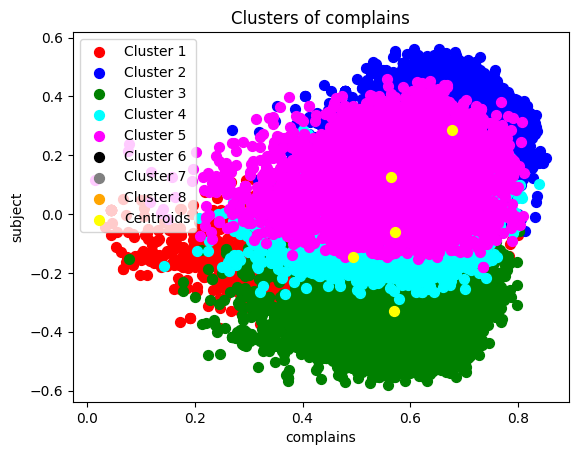

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 50, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 50, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 50, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 50, c = 'magenta', label = 'Cluster 5')
plt.scatter(X[y_kmeans == 5, 0], X[y_kmeans == 5, 1], s = 50, c = 'black', label = 'Cluster 6')
plt.scatter(X[y_kmeans == 6, 0], X[y_kmeans == 6, 1], s = 50, c = 'grey', label = 'Cluster 7')
plt.scatter(X[y_kmeans == 7, 0], X[y_kmeans == 7, 1], s = 50, c = 'orange', label = 'Cluster 8')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 50, c = 'yellow', label = 'Centroids')
plt.title('Clusters of complains')
plt.xlabel('complains')
plt.ylabel('subject')
plt.legend()
plt.show()